# Exploratory Data Analysis (EDA)

Project:
MarketMind AI

Module:
Forecasting & Time Series Analysis

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [5]:
df=pd.read_csv("../data/dataset.csv")

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Category,Sub-Category,Product Name,Total amount,Quantity,Discount,Profit,Shipping Cost,Order Priority,unit_price
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical,329.950
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,412.155
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,575.019
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,578.502
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,354.120


In [8]:
df.shape

(51290, 25)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   City            51290 non-null  str    
 9   State           51290 non-null  str    
 10  Country         51290 non-null  str    
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  str    
 13  Region          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 non-null  str    
 1

In [ ]:
#Converting order date and ship date to datetime data type
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  str           
 2   Order Date      51290 non-null  datetime64[us]
 3   Ship Date       51290 non-null  datetime64[us]
 4   Ship Mode       51290 non-null  str           
 5   Customer ID     51290 non-null  str           
 6   Customer Name   51290 non-null  str           
 7   Segment         51290 non-null  str           
 8   City            51290 non-null  str           
 9   State           51290 non-null  str           
 10  Country         51290 non-null  str           
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  str           
 13  Region          51290 non-null  str           
 14  Product ID      51290 non-null  str           
 15  Category     

C:\Users\Rakshitha\AppData\Local\Temp\ipykernel_5232\1095006118.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Ship Date']=pd.to_datetime(df['Ship Date'])


In [12]:
df.describe(include='all')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Category,Sub-Category,Product Name,Total amount,Quantity,Discount,Profit,Shipping Cost,Order Priority,unit_price
count,51290.00000,51290,51290,51290,51290,51290,51290,51290,51290,51290,...,51290,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290,51290.000000
unique,NaN,25035,NaN,NaN,4,1590,795,3,3636,1094,...,3,17,3788,NaN,NaN,NaN,NaN,NaN,4,NaN
top,NaN,CA-2014-100111,NaN,NaN,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,...,Office Supplies,Binders,Staples,NaN,NaN,NaN,NaN,NaN,Medium,NaN
freq,NaN,14,NaN,NaN,30775,97,108,26518,915,2001,...,31273,6152,227,NaN,NaN,NaN,NaN,NaN,29433,NaN
mean,25645.50000,NaN,2013-05-11 21:26:49.155780,2013-05-15 20:42:42.745174,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,246.490581,3.476545,0.142908,28.610982,26.375915,NaN,71.657487
min,1.00000,NaN,2011-01-01 00:00:00,2011-01-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000,0.000000,NaN,0.336000
25%,12823.25000,NaN,2012-06-19 00:00:00,2012-06-23 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,30.758625,2.000000,0.000000,0.000000,2.610000,NaN,11.799900
50%,25645.50000,NaN,2013-07-08 00:00:00,2013-07-12 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,85.053000,3.000000,0.000000,9.240000,7.790000,NaN,29.400000
75%,38467.75000,NaN,2014-05-22 00:00:00,2014-05-26 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,251.053200,5.000000,0.200000,36.810000,24.450000,NaN,82.160000
max,51290.00000,NaN,2014-12-31 00:00:00,2015-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,22638.480000,14.000000,0.850000,8399.976000,933.570000,NaN,3773.080000


In [20]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Total amount      0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
unit_price        0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

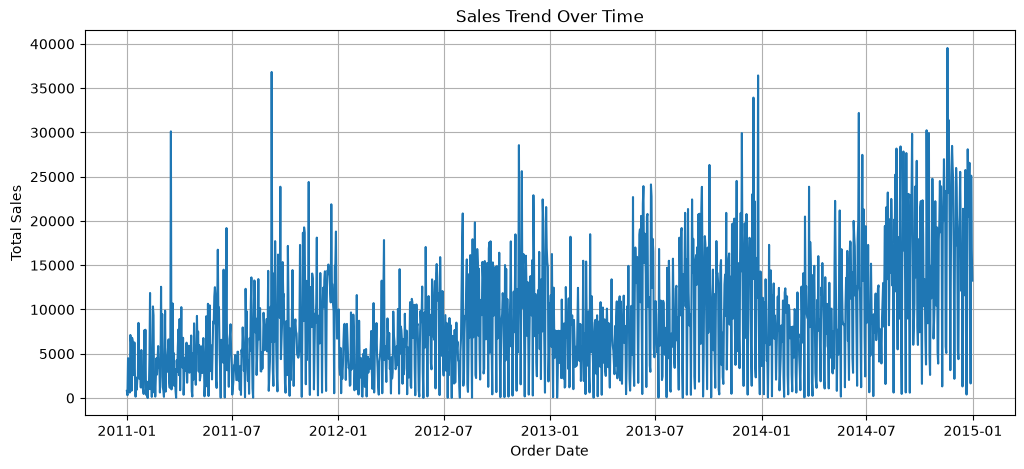

In [22]:
#Sales Trend
daily_sales = df.groupby("Order Date")["Total amount"].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_sales.index, daily_sales.to_numpy())
plt.title("Sales Trend Over Time")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

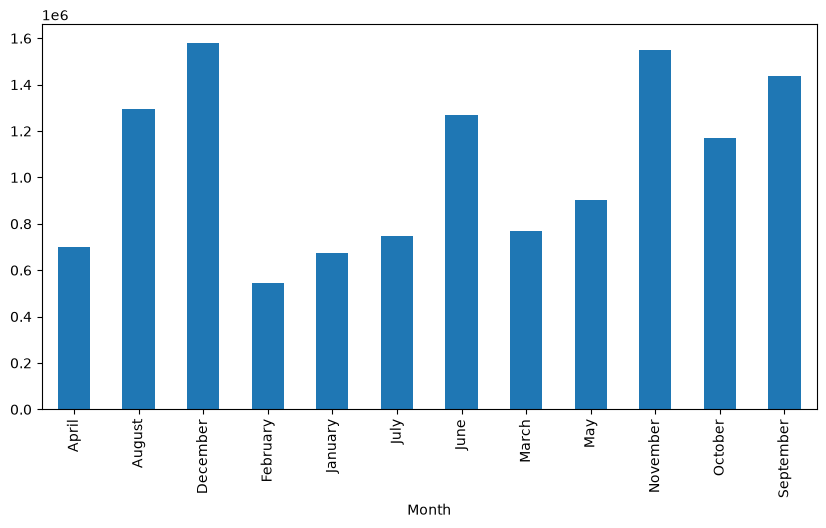

In [23]:
#Monthly Sales
df["Month"] = df["Order Date"].dt.month_name()

monthly_sales = df.groupby("Month")["Total amount"].sum()

monthly_sales.plot(kind="bar", figsize=(10,5))
plt.show()

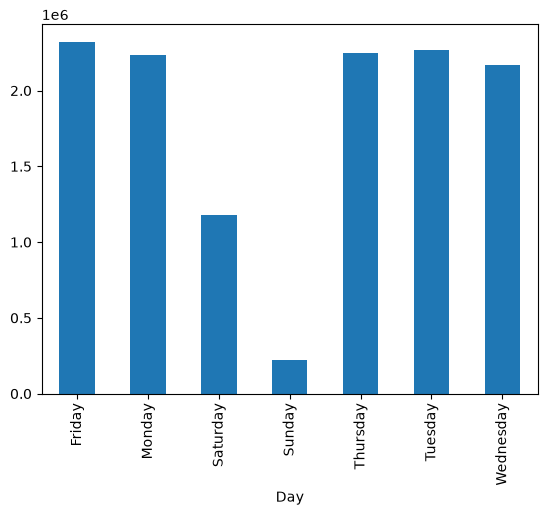

In [24]:
#weekly sales
df["Day"] = df["Order Date"].dt.day_name()

weekly_sales = df.groupby("Day")["Total amount"].sum()

weekly_sales.plot(kind="bar")
plt.show()

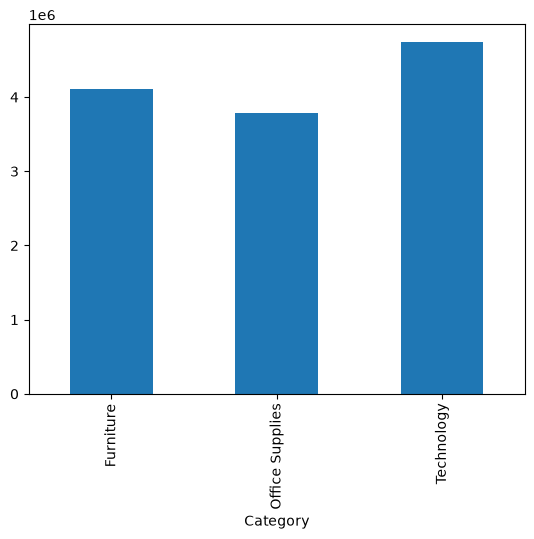

In [25]:
#category-wise sales
category_sales = df.groupby("Category")["Total amount"].sum()

category_sales.plot(kind="bar")
plt.show()

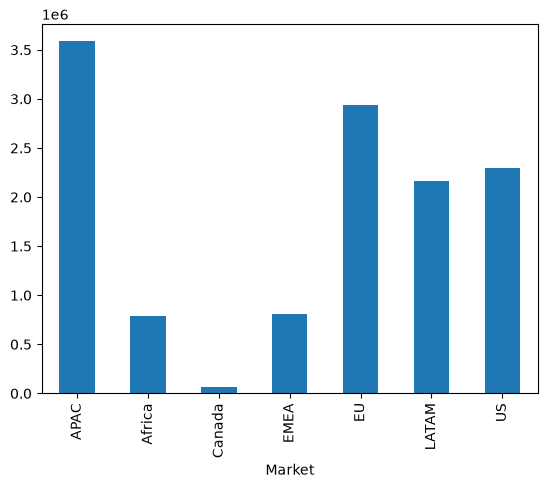

In [26]:
#market-wise sales
market_sales = df.groupby("Market")["Total amount"].sum()

market_sales.plot(kind="bar")
plt.show()

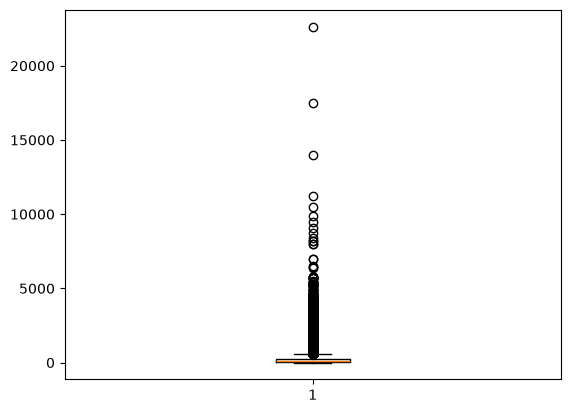

In [27]:
#outlier detection
plt.boxplot(df["Total amount"])
plt.show()

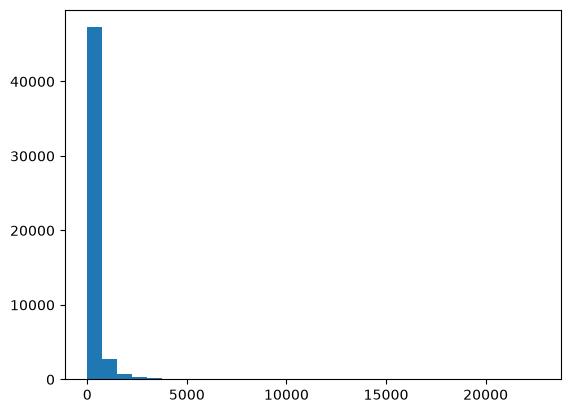

In [28]:
#Histogram 
plt.hist(df["Total amount"], bins=30)
plt.show()

              Quantity  unit_price  Discount  Total amount
Quantity      1.000000   -0.010161 -0.019875      0.313577
unit_price   -0.010161    1.000000 -0.115432      0.809084
Discount     -0.019875   -0.115432  1.000000     -0.086722
Total amount  0.313577    0.809084 -0.086722      1.000000


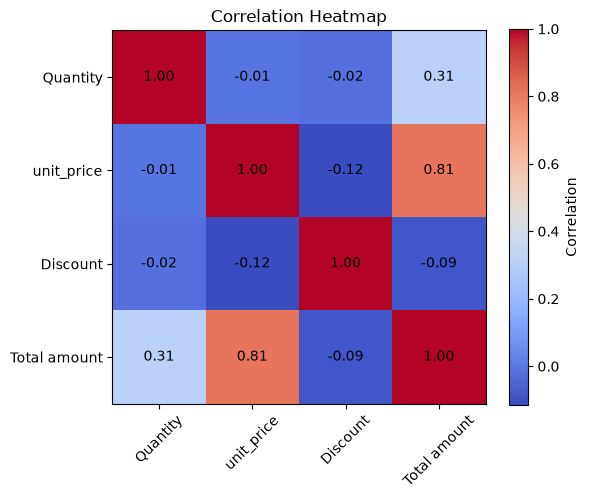

In [29]:
#Correlation Matrix and Heat Map

corr = df[["Quantity", "unit_price", "Discount", "Total amount"]].corr()

print(corr)

# Heatmap
plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlation")

# Axis labels
plt.xticks(range(len(corr.columns)), corr.columns.tolist(), rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns.tolist())

# Display correlation values inside each cell
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()